In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:

# Load dữ liệu
train = pd.read_csv('data/train (1).csv')

In [92]:
from sklearn.preprocessing import StandardScaler

# Sau đó mới chạy đoạn này
scaler = StandardScaler()
# ... các bước tiếp theo

In [93]:

# 1. Kiểm tra thông tin tổng quát
print("--- Thông tin tổng quát ---")
print(train.info())

--- Thông tin tổng quát ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14396 entries, 0 to 14395
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  14396 non-null  int64  
 1   Artist Name         14396 non-null  object 
 2   Track Name          14396 non-null  object 
 3   Popularity          14063 non-null  float64
 4   danceability        14396 non-null  float64
 5   energy              14396 non-null  float64
 6   key                 12787 non-null  float64
 7   loudness            14396 non-null  float64
 8   mode                14396 non-null  int64  
 9   speechiness         14396 non-null  float64
 10  acousticness        14396 non-null  float64
 11  instrumentalness    10855 non-null  float64
 12  liveness            14396 non-null  float64
 13  valence             14396 non-null  float64
 14  tempo               14396 non-null  float64
 15  duration_in min/ms  14396

In [94]:

# 2. Kiểm tra giá trị thiếu
missing_data = train.isnull().sum()
print("\n--- Số lượng giá trị thiếu mỗi cột ---")
print(missing_data[missing_data > 0])


--- Số lượng giá trị thiếu mỗi cột ---
Popularity           333
key                 1609
instrumentalness    3541
dtype: int64


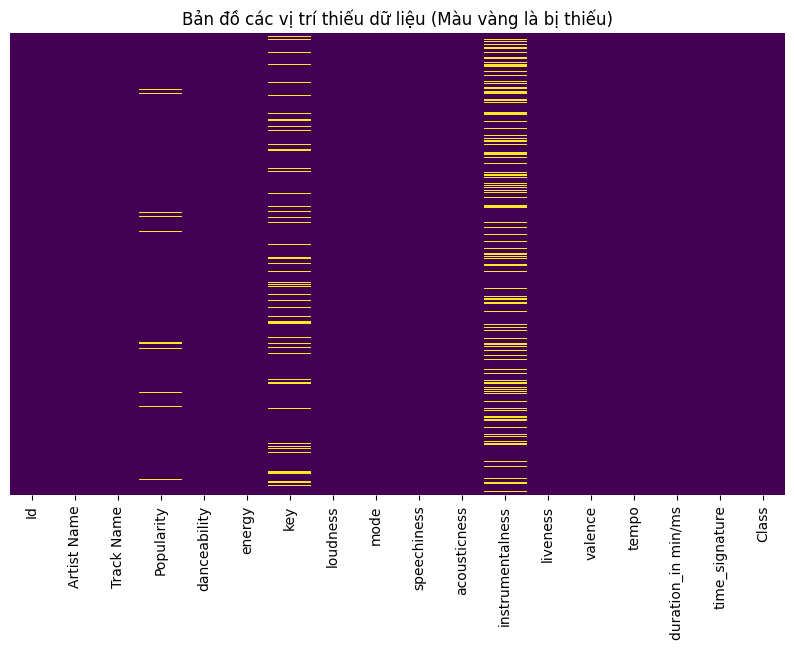

In [95]:

# Trực quan hóa giá trị thiếu
plt.figure(figsize=(10, 6))
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Bản đồ các vị trí thiếu dữ liệu (Màu vàng là bị thiếu)')
plt.show()

In [96]:
# Quy đổi toàn bộ về miligiây
def fix_duration(x):
    if x < 30: # Ngưỡng 30 phút, nếu nhỏ hơn thì chắc chắn là đơn vị phút
        return x * 60000
    return x

train['duration_fixed'] = train['duration_in min/ms'].apply(fix_duration)

C:\Users\HI\AppData\Local\Temp\ipykernel_15272\3947344561.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=train, palette='viridis')


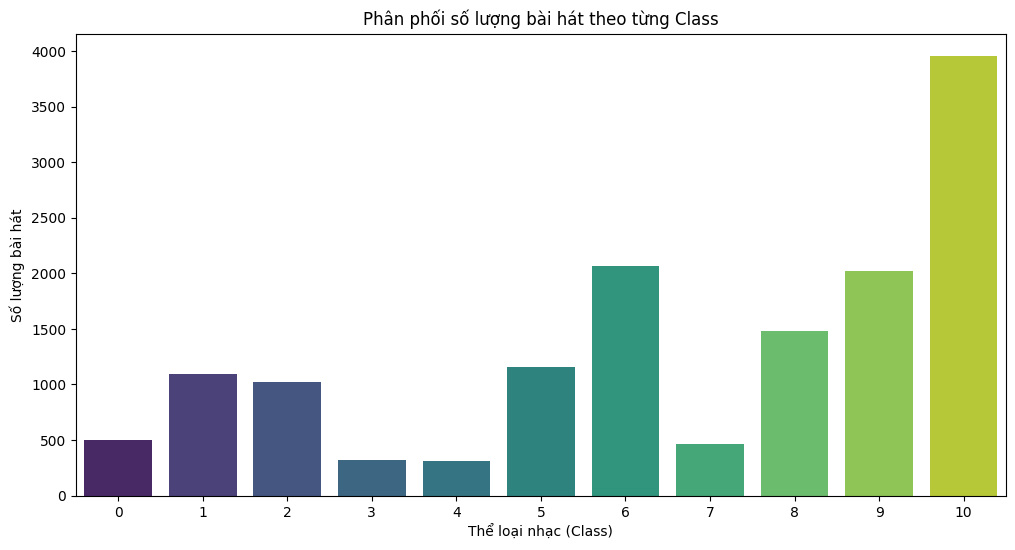

Class
10    27.500695
6     14.372048
9     14.024729
8     10.301473
5      8.036955
1      7.627119
2      7.071409
0      3.473187
7      3.202278
3      2.236732
4      2.153376
Name: proportion, dtype: float64


In [97]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Class', data=train, palette='viridis')
plt.title('Phân phối số lượng bài hát theo từng Class')
plt.xlabel('Thể loại nhạc (Class)')
plt.ylabel('Số lượng bài hát')
plt.show()

# Tính tỷ lệ phần trăm cụ thể
print(train['Class'].value_counts(normalize=True) * 100)

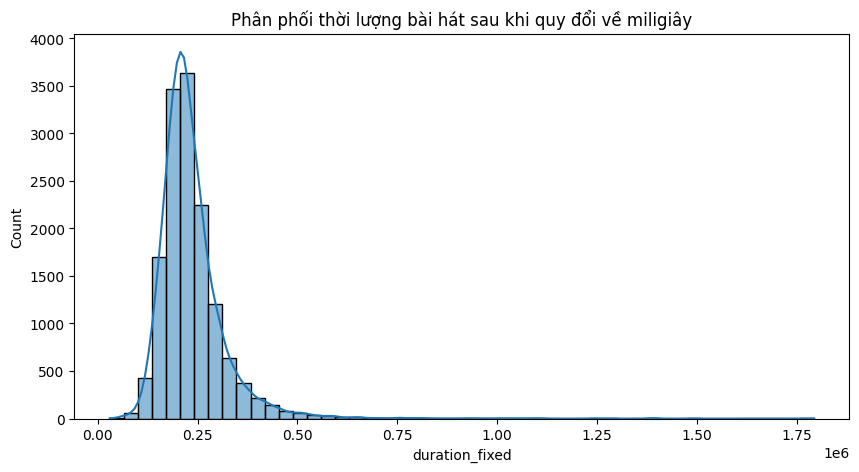

In [98]:
def fix_duration(duration):
    # Nếu thời gian < 30, ta coi đó là phút và đổi sang miligiây (30 phút là ngưỡng an toàn cho 1 bài hát)
    if duration < 30:
        return duration * 60000
    return duration

# Áp dụng hàm sửa lỗi
train['duration_fixed'] = train['duration_in min/ms'].apply(fix_duration)

# Kiểm tra thử kết quả sau khi sửa
plt.figure(figsize=(10, 5))
sns.histplot(train['duration_fixed'], bins=50, kde=True)
plt.title('Phân phối thời lượng bài hát sau khi quy đổi về miligiây')
plt.show()

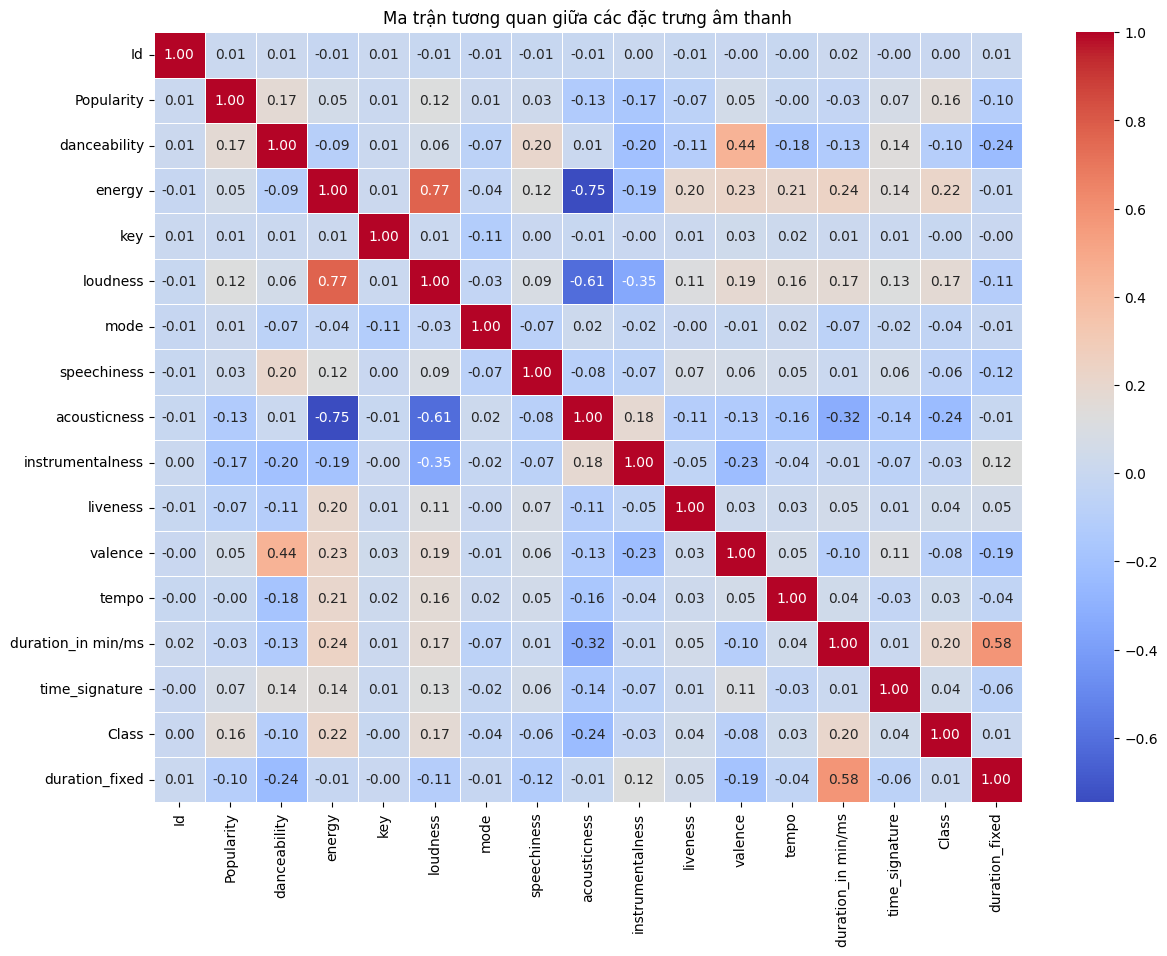

In [99]:
# Chỉ lấy các cột dữ liệu số để tính tương quan
numeric_cols = train.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng âm thanh')
plt.show()

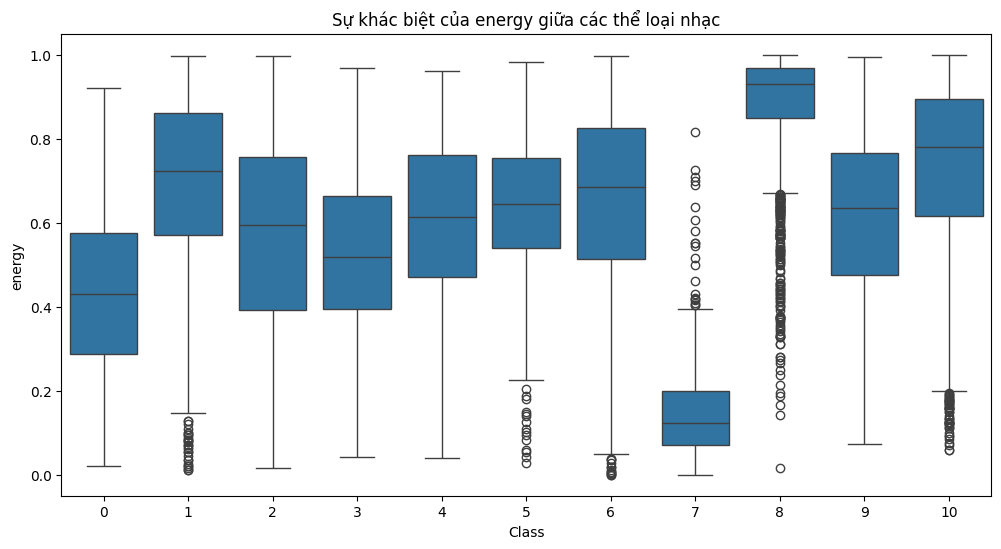

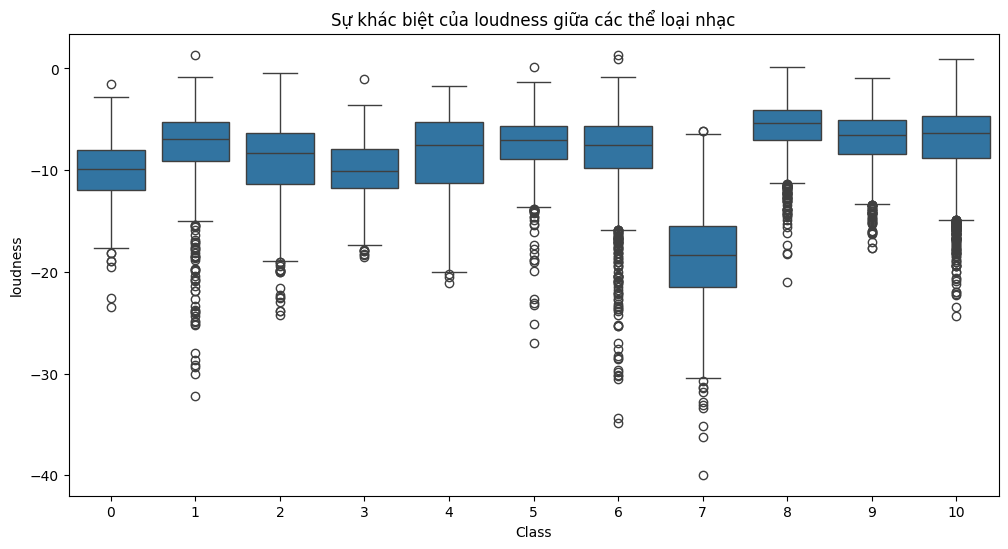

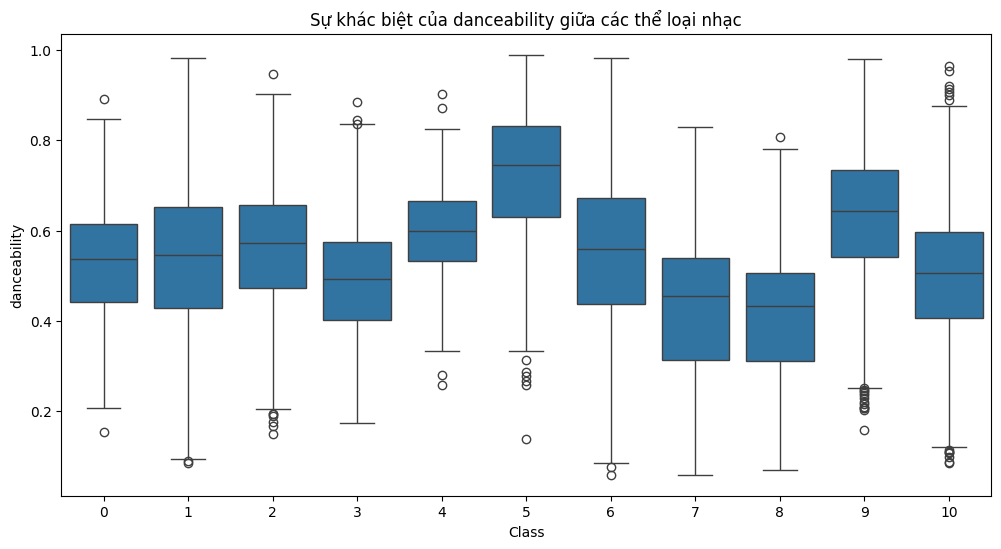

In [100]:
# Ví dụ phân tích sự khác biệt về 'Energy' và 'Loudness' giữa các Class
features_to_plot = ['energy', 'loudness', 'danceability']

for feature in features_to_plot:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Class', y=feature, data=train)
    plt.title(f'Sự khác biệt của {feature} giữa các thể loại nhạc')
    plt.show()

In [101]:
import pandas as pd

# Load dữ liệu (Đảm bảo file nằm trong thư mục data)
train = pd.read_csv('data/train (1).csv')
test = pd.read_csv('data/test (2).csv')

# 1. Xóa thẳng tay 2 cột bị hỏng nặng theo ý bạn
# Dùng errors='ignore' để tránh lỗi nếu bạn lỡ chạy code này 2 lần
train.drop(['instrumentalness', 'key'], axis=1, inplace=True, errors='ignore')
test.drop(['instrumentalness', 'key'], axis=1, inplace=True, errors='ignore')

# 2. Điền giá trị thiếu cho Popularity bằng Median (Trung vị)
# Median giúp tránh các giá trị ngoại lai (bài quá hot hoặc quá ít người nghe)
pop_median = train['Popularity'].median()
train['Popularity'] = train['Popularity'].fillna(pop_median)
test['Popularity'] = test['Popularity'].fillna(pop_median)

# 3. FIX LỖI THỜI GIAN (Cái này cực quan trọng để model chính xác)
def fix_duration(x):
    # Nếu nhỏ hơn 25 (phút), đổi sang miligiây. Ngược lại giữ nguyên.
    return x * 60000 if x < 25 else x

train['duration_in min/ms'] = train['duration_in min/ms'].apply(fix_duration)
test['duration_in min/ms'] = test['duration_in min/ms'].apply(fix_duration)

# Kiểm tra lại xem còn giá trị thiếu nào không
print("--- Kiểm tra dữ liệu sau khi xử lý ---")
print(train.isnull().sum())
print("\nCác cột hiện có:", train.columns.tolist())

--- Kiểm tra dữ liệu sau khi xử lý ---
Id                    0
Artist Name           0
Track Name            0
Popularity            0
danceability          0
energy                0
loudness              0
mode                  0
speechiness           0
acousticness          0
liveness              0
valence               0
tempo                 0
duration_in min/ms    0
time_signature        0
Class                 0
dtype: int64

Các cột hiện có: ['Id', 'Artist Name', 'Track Name', 'Popularity', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature', 'Class']


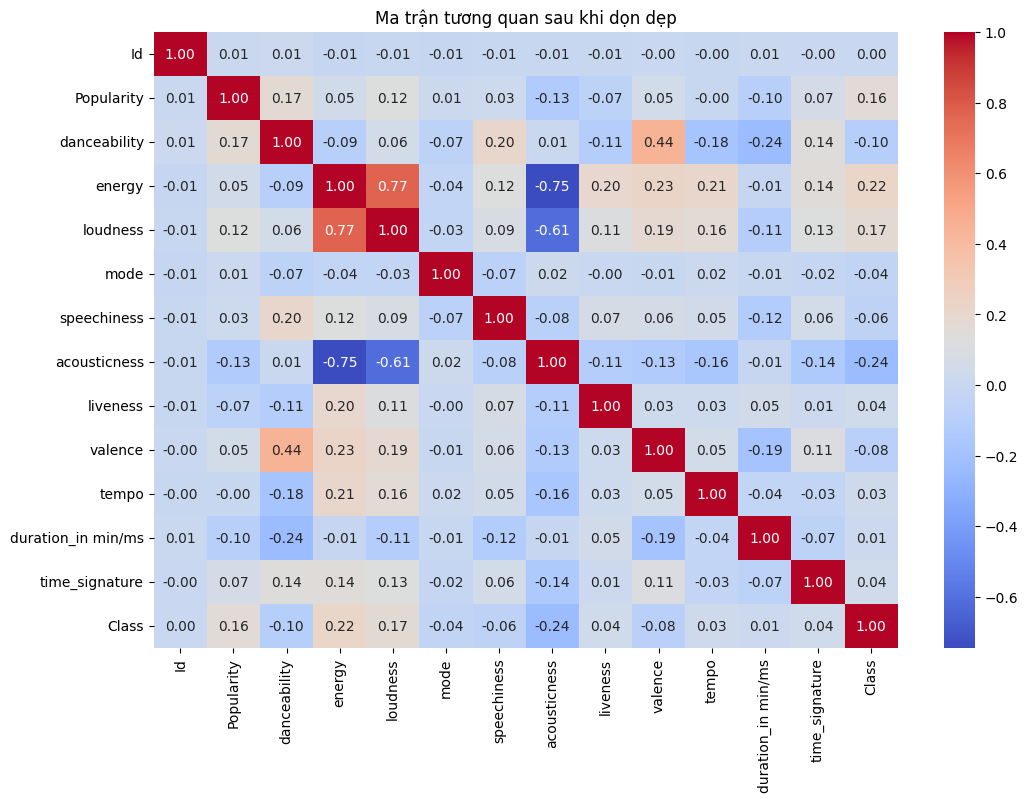

In [102]:
plt.figure(figsize=(12, 8))
sns.heatmap(train.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan sau khi dọn dẹp')
plt.show()

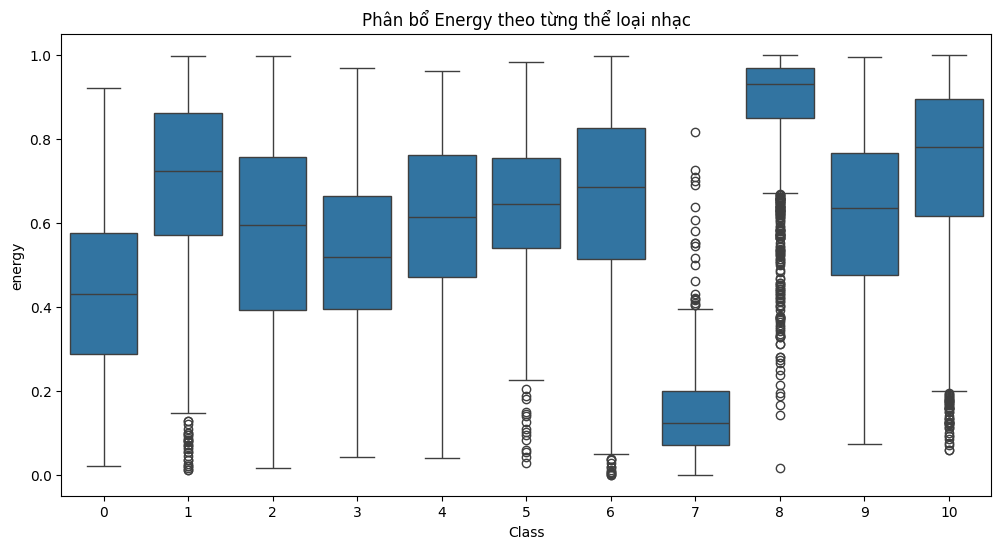

In [103]:
# Xem thử đặc trưng Energy phân bố thế nào giữa các Class
plt.figure(figsize=(12, 6))
sns.boxplot(x='Class', y='energy', data=train)
plt.title('Phân bổ Energy theo từng thể loại nhạc')
plt.show()

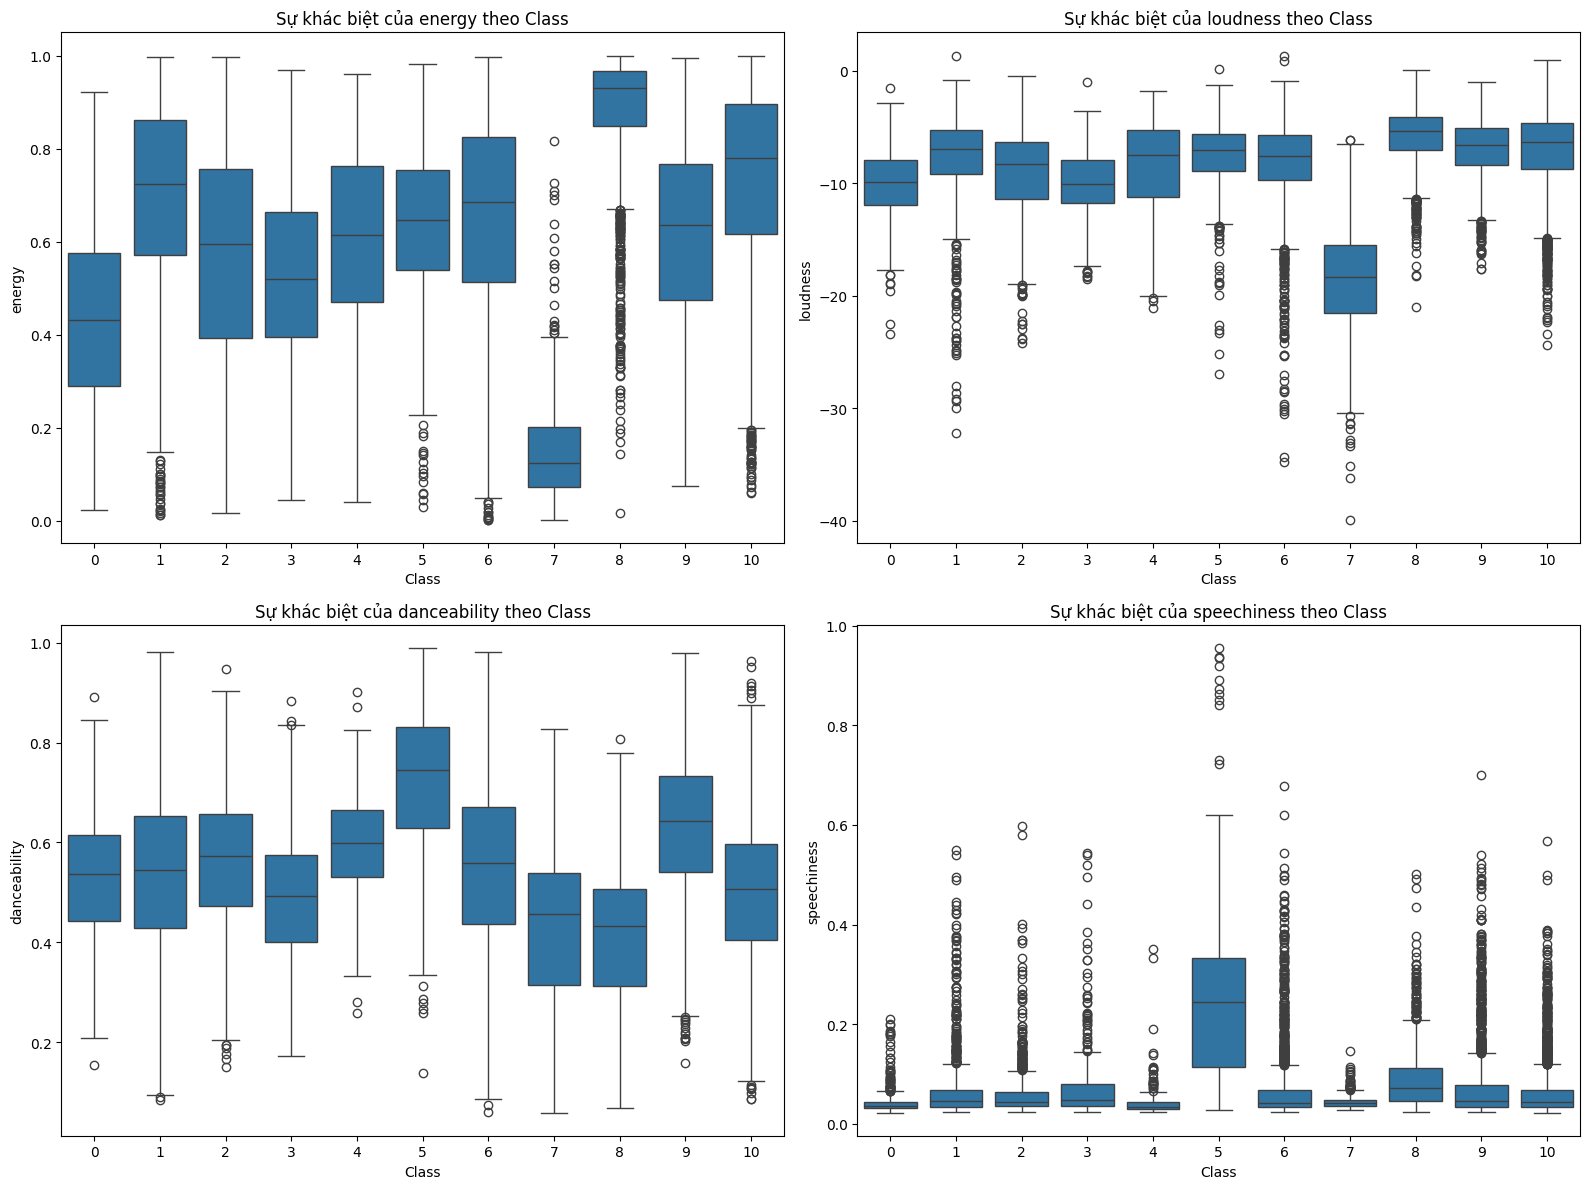

In [104]:
# Xem sự khác biệt của Energy và Loudness giữa các thể loại
features = ['energy', 'loudness', 'danceability', 'speechiness']
plt.figure(figsize=(16, 12))

for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='Class', y=col, data=train)
    plt.title(f'Sự khác biệt của {col} theo Class')

plt.tight_layout()
plt.show()

Top 10 nghệ sĩ xuất hiện nhiều nhất:
 Artist Name
Backstreet Boys    58
Westlife           53
Britney Spears     47
Omer Adam          39
Eyal Golan         38
Shlomo Artzi       32
Dudu Aharon        29
Arik Einstein      29
Hadag Nahash       29
Moshe Peretz       27
Name: count, dtype: int64


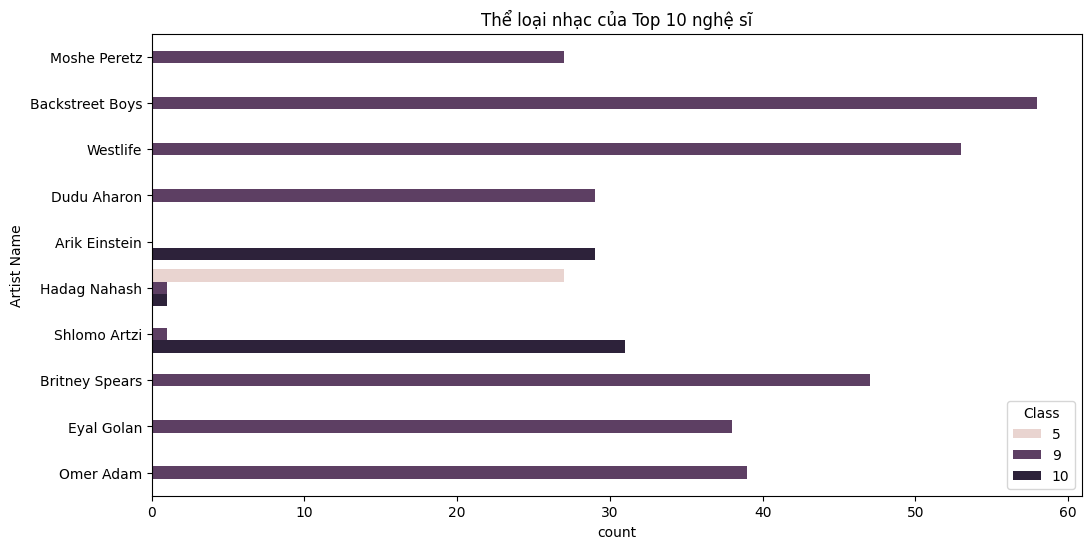

In [105]:
# Xem 10 nghệ sĩ xuất hiện nhiều nhất
top_artists = train['Artist Name'].value_counts().head(10)
print("Top 10 nghệ sĩ xuất hiện nhiều nhất:\n", top_artists)

# Trực quan hóa xem nghệ sĩ đó hát thể loại gì
plt.figure(figsize=(12, 6))
top_10_df = train[train['Artist Name'].isin(top_artists.index)]
sns.countplot(y='Artist Name', hue='Class', data=top_10_df)
plt.title('Thể loại nhạc của Top 10 nghệ sĩ')
plt.show()

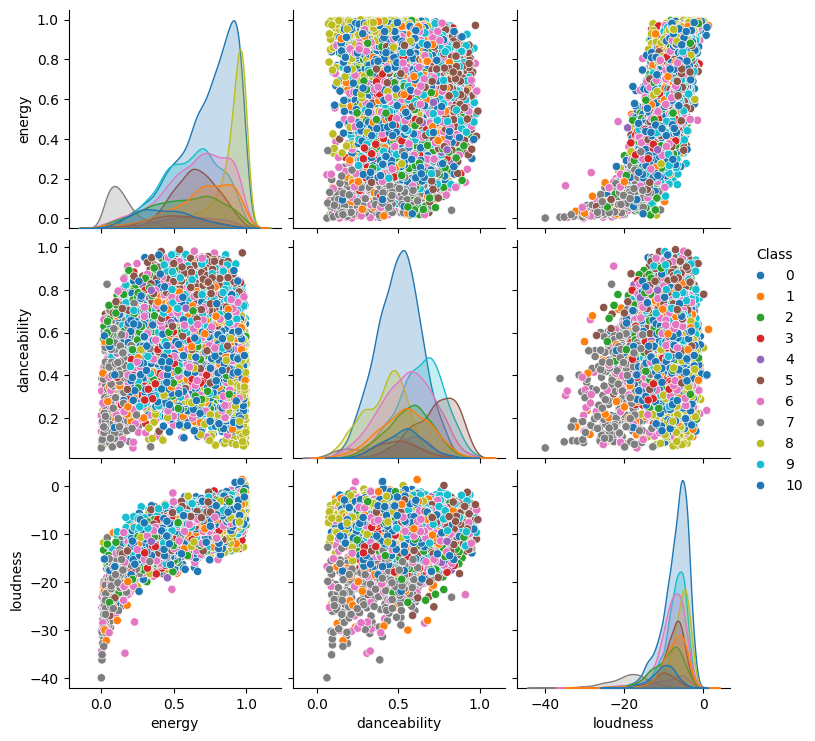

In [106]:
# Chọn vài biến đại diện để vẽ nhanh
sns.pairplot(train[['energy', 'danceability', 'loudness', 'Class']], hue='Class', palette='tab10')
plt.show()

C:\Users\HI\AppData\Local\Temp\ipykernel_15272\2295818829.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=train, palette='viridis')
C:\Users\HI\AppData\Local\Temp\ipykernel_15272\2295818829.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=train, palette='viridis')
C:\Users\HI\AppData\Local\Temp\ipykernel_15272\2295818829.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=train, palette='viridis')
C:\Users\HI\AppData\Local\Temp\ipykernel_15272\2295818829.py:7: Future

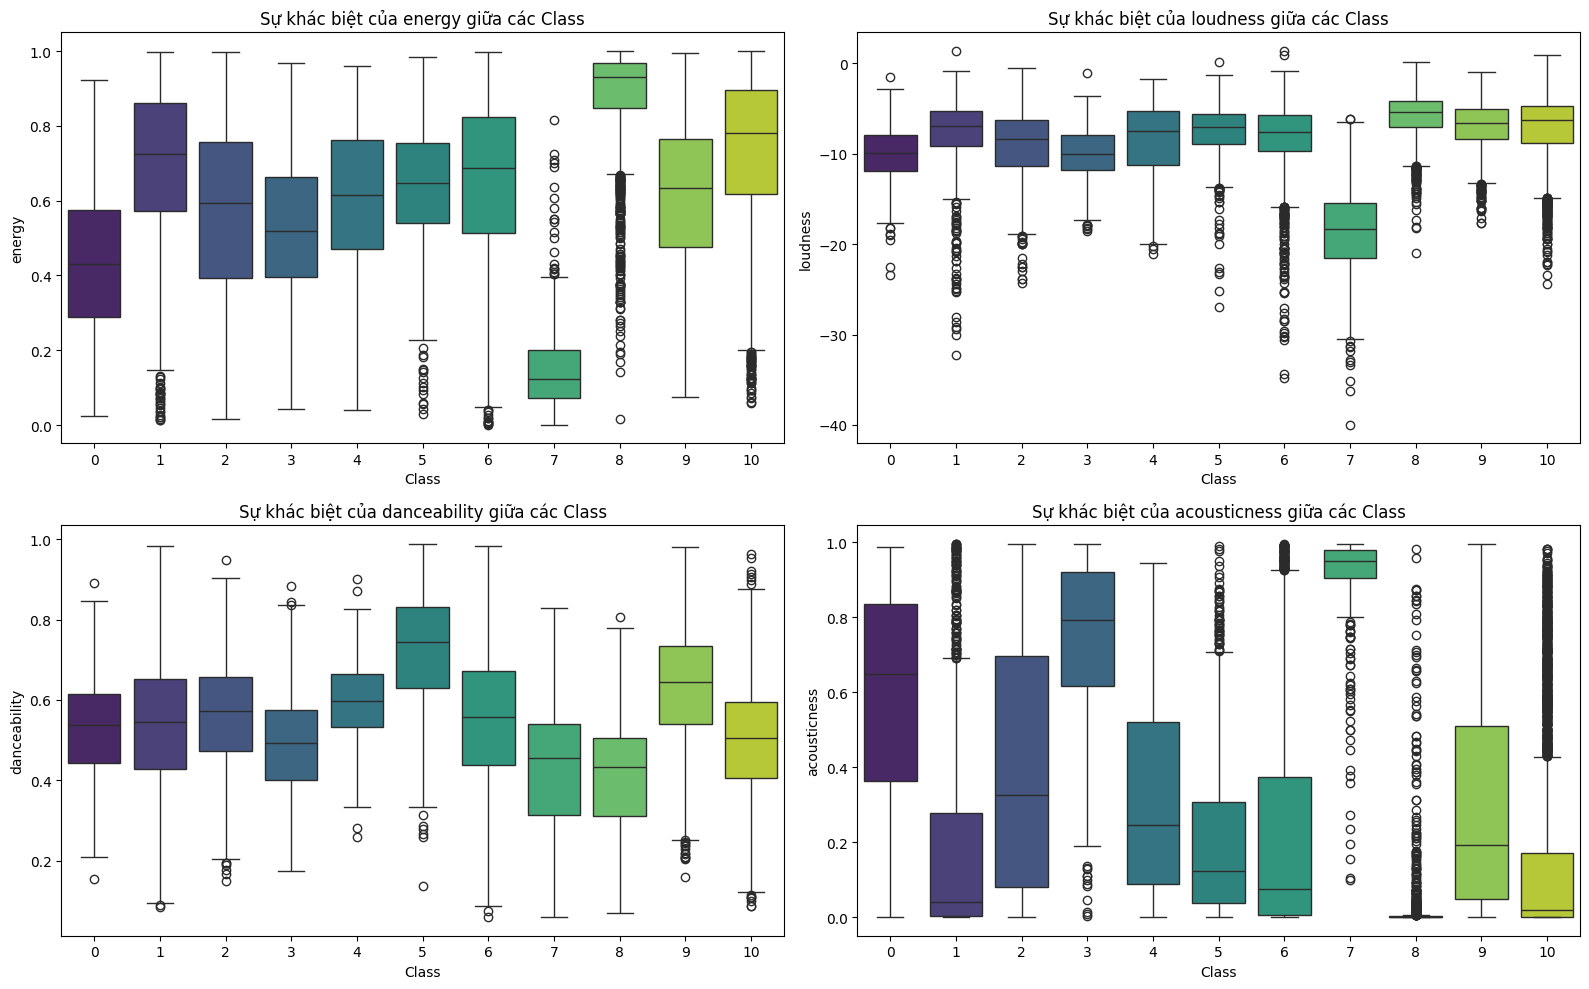

In [107]:
# Vẽ biểu đồ Boxplot cho 4 đặc trưng quan trọng nhất
features = ['energy', 'loudness', 'danceability', 'acousticness']
plt.figure(figsize=(16, 10))

for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='Class', y=col, data=train, palette='viridis')
    plt.title(f'Sự khác biệt của {col} giữa các Class')

plt.tight_layout()
plt.show()

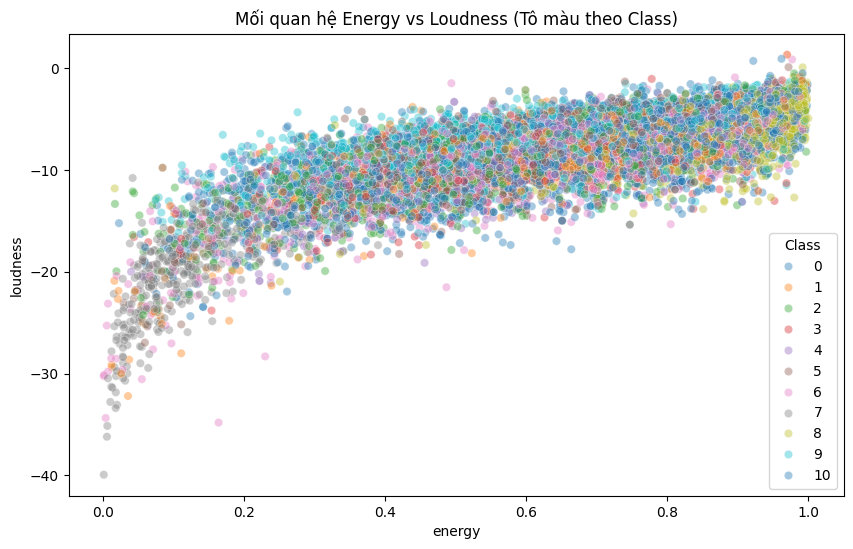

In [108]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train, x='energy', y='loudness', hue='Class', palette='tab10', alpha=0.4)
plt.title('Mối quan hệ Energy vs Loudness (Tô màu theo Class)')
plt.show()

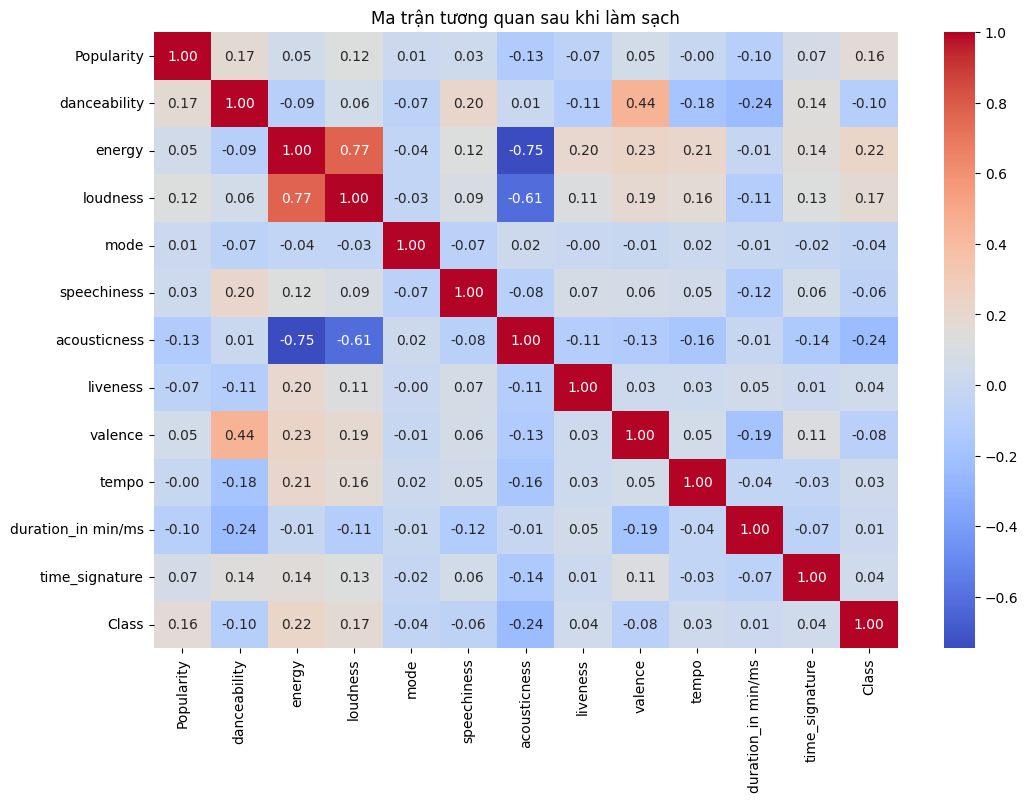

In [109]:
plt.figure(figsize=(12, 8))
numeric_cols = train.select_dtypes(include=[np.number]).drop(columns=['Id'], errors='ignore')
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Ma trận tương quan sau khi làm sạch')
plt.show()

In [110]:
from sklearn.preprocessing import StandardScaler

# 1. Đầu tiên, tạo cột duration_ms từ cột gốc (nếu chưa có)
def fix_duration(x):
    return x * 60000 if x < 25 else x

train['duration_ms'] = train['duration_in min/ms'].apply(fix_duration)
test['duration_ms'] = test['duration_in min/ms'].apply(fix_duration)

# 2. Xác định danh sách các cột thực sự ĐANG CÓ trong dữ liệu của bạn
# Mình đã bỏ key và instrumentalness theo ý bạn ở trên
features_to_scale = ['Popularity', 'danceability', 'energy', 'loudness', 
                    'speechiness', 'acousticness', 'liveness', 'valence', 
                    'tempo', 'duration_ms']

# 3. Tiến hành Scaling
scaler = StandardScaler()

# Fit và transform cho train
train_scaled = train.copy()
train_scaled[features_to_scale] = scaler.fit_transform(train[features_to_scale])

# Transform cho test
test_scaled = test.copy()
test_scaled[features_to_scale] = scaler.transform(test[features_to_scale])

print("Ngon rồi! Đã scale xong các cột:", features_to_scale)

Ngon rồi! Đã scale xong các cột: ['Popularity', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'liveness', 'valence', 'tempo', 'duration_ms']


In [111]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [112]:
from sklearn.model_selection import train_test_split

# 1. Xác định X (đầu vào) và y (nhãn dự đoán)
# features_to_scale là danh sách các cột bạn đã chuẩn hóa
X = train_scaled[features_to_scale] 
y = train_scaled['Class']

# 2. Chia dữ liệu thành 2 phần: 80% để học (train) và 20% để thi thử (validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Sau khi chạy xong dòng này, biến 'y_train' mới tồn tại để bạn dùng cho XGBoost

In [113]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# 1. Chuẩn bị dữ liệu (Nếu nhãn của bạn bắt đầu từ 1, hãy trừ 1 để về 0-10)
y_train_adjusted = y_train - y_train.min()
y_val_adjusted = y_val - y_val.min()

# 2. Khởi tạo model XGBoost
# objective='multi:softmax' dùng cho bài toán phân loại nhiều lớp
# num_class là số lượng thể loại nhạc (ví dụ: 11)
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softmax',
    num_class=len(y.unique()),
    random_state=42
)

# 3. Huấn luyện
xgb_model.fit(X_train, y_train_adjusted)

# 4. Dự đoán và đánh giá
y_pred_xgb = xgb_model.predict(X_val)
print("XGBoost Accuracy:", accuracy_score(y_val_adjusted, y_pred_xgb))

XGBoost Accuracy: 0.4673611111111111


In [114]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,         # Tăng số cây lên
    learning_rate=0.02,        # Giảm tốc độ học để học kỹ hơn
    max_depth=5,               # Giảm độ sâu để tránh học vẹt
    subsample=0.8,             # Mỗi cây chỉ lấy 80% dữ liệu (tránh nhiễu)
    colsample_bytree=0.8,      # Mỗi cây chỉ lấy 80% cột
    early_stopping_rounds=50,  # Dừng khi không còn tiến bộ
    objective='multi:softmax',
    num_class=11,
    random_state=42
)

# Khi fit nhớ thêm eval_set để nó biết đường mà early stopping
xgb_model.fit(X_train, y_train_adjusted, 
              eval_set=[(X_val, y_val_adjusted)], 
              verbose=False)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


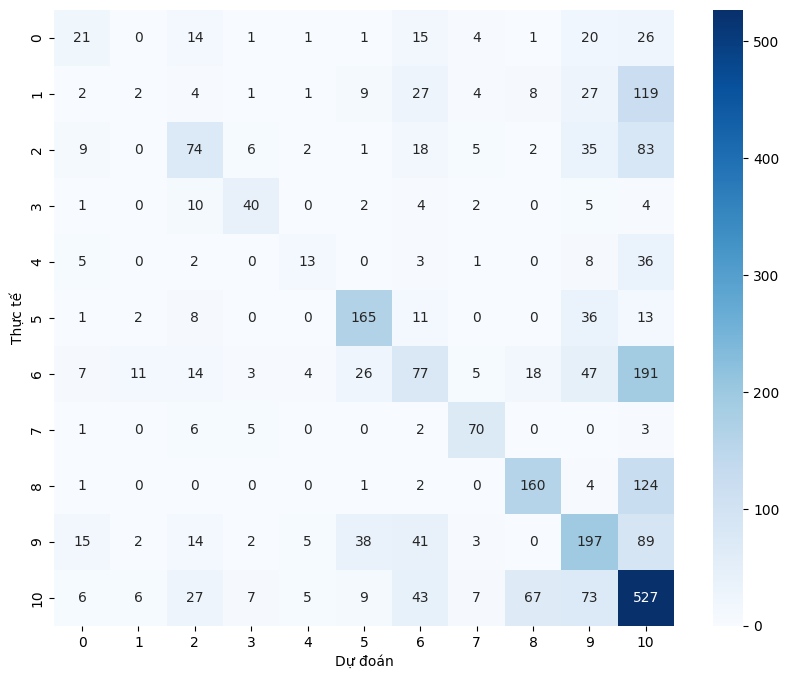

In [115]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val_adjusted, y_pred_xgb)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

In [116]:
train_scaled['energy_loudness'] = train_scaled['energy'] * train_scaled['loudness']
train_scaled['dance_valence'] = train_scaled['danceability'] * train_scaled['valence']

In [117]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [118]:

from category_encoders import TargetEncoder

encoder = TargetEncoder(cols=['Artist Name'])
train_scaled['Artist_Encoded'] = encoder.fit_transform(train['Artist Name'], train['Class'])
test_scaled['Artist_Encoded'] = encoder.transform(test['Artist Name'])

# Nhớ thêm 'Artist_Encoded' vào danh sách features_to_scale/features_to_train

In [120]:
from sklearn.utils.class_weight import compute_sample_weight

# 1. Tính toán trọng số dựa trên số lượng mẫu của từng Class
# 'balanced' sẽ tự động tính trọng số tỉ lệ nghịch với tần suất xuất hiện
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_adjusted)

# 2. Đưa trọng số này vào lúc Train
xgb_model.fit(X_train, y_train_adjusted, sample_weight=sample_weights)

# 3. Dự đoán lại
y_pred_weighted = xgb_model.predict(X_val)

ValueError: Must have at least 1 validation dataset for early stopping.